The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


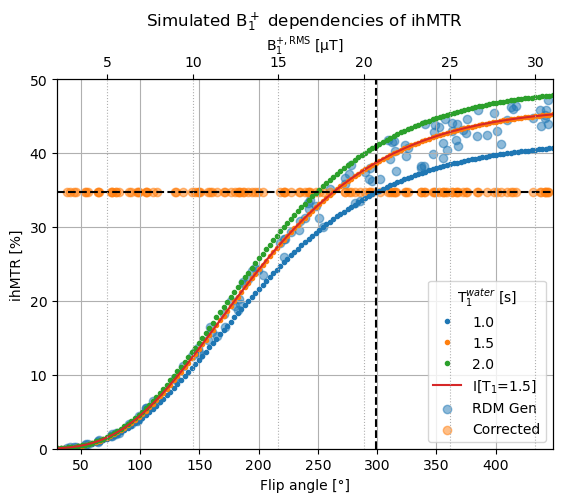

In [54]:
%load_ext autoreload
%autoreload 2

from brainhack.pulse import Tukey
from brainhack.sequence import Sequence, Modulation
from brainhack.system import System
from brainhack.simulator import Simulator
from brainhack.corrector import Corrector, Correctable

import matplotlib.pyplot as plt
import numpy as np

pulse = Tukey(
    duration = 1e-3,                    # in s
    shape = .3,
    flipAngle = 299,                    # in degree
    offset = 7000                       # in Hz
)

sequence = Sequence(
    modulation = Modulation.BP,
    pulse = pulse,
    N_pulsePerOffset = 1,
    N_pulse = 6,
    N_burst = 10,
    N_adc = 96,
    N_dummyADC = 0,
    dt_interPulse = 1.5e-3,             # in s
    TR_burst = 100e-3,                  # in s
    dt_lastBurst = 9e-3,                # in s
    es = 6e-3,                          # in s
    tr = 20,                            # in s
    readout_flipAngle = 6               # in degree
)

system = System(
    pulse = pulse,
    poolFree_M0 = 1,
    poolBound_M0 = 0.1,
    poolFree_T1 = 1,                    # in s
    poolBound_T1 = 1,                   # in s 
    poolBound_T1D = 0.01,               # in s
    poolFree_T2 = 0.1,                  # in s
    poolBound_T2 = 1e-5,                # in s
    poolFreeBound_exchangeRate = 20     # in s^-1
)

simulator = Simulator(
    system = system,
    sequence = sequence,
    output_vectorSlice = slice(1),
    export_readMatrix = False,
)

corrector = Corrector.Simple(simulator)
nominals = corrector.nominals
# print(nominals[Correctable.ihMTR_CM])

# print(corrector.simulated[Correctable.ihMTR_CM])
# corrector.simulated[Correctable.ihMTR_CM]

original_flipAngle = corrector.simulator.pulse.flipAngle

interp_T1 = 1.5

interp = corrector.interpolants[Correctable.ihMTR_CM]
x = corrector.mesh['flipAngle'].T.squeeze()
ranges = np.vstack([interp_T1 * np.ones_like(x), x]).T

# B1 Correction
shape = (5, 5, 5)
T1 = np.random.random(shape) * (max(corrector.ranges['poolFree_T1']) - min(corrector.ranges['poolFree_T1'])) + min(corrector.ranges['poolFree_T1'])
B1 = np.random.random(shape) * (max(corrector.ranges['flipAngle']) - min(corrector.ranges['flipAngle'])) + min(corrector.ranges['flipAngle'])
params = {'flipAngle': B1, 'poolFree_T1': T1}
data = {Correctable.ihMTR_CM: interp(np.vstack([T1.flatten(), B1.flatten()]).T).reshape(shape)}
corrected = corrector.apply(params, data)

plt.plot(x, corrector.simulated[Correctable.ihMTR_CM].T, '.', label=corrector.ranges['poolFree_T1'])
plt.plot(x, interp(ranges), label=r'I[$\mathrm{T}_1$=' + f'{interp_T1}]')

plt.scatter(B1.flatten(), data[Correctable.ihMTR_CM].flatten(), label='RDM Gen', alpha=.5)
plt.scatter(B1.flatten(), corrected[Correctable.ihMTR_CM].flatten(), label='Corrected', alpha=.5)

plt.vlines(original_flipAngle, 0, 50, 'k', 'dashed')
plt.hlines(nominals[Correctable.ihMTR_CM], min(corrector.ranges['flipAngle']), max(corrector.ranges['flipAngle']), 'k', 'dashed')

plt.legend(title=r'$\mathrm{T}_1^{water}$ [s]')
plt.xlabel('Flip angle [°]')
plt.xlim(min(corrector.ranges['flipAngle']), max(corrector.ranges['flipAngle']))

plt.ylim(0, 50)
plt.ylabel('ihMTR [%]')

plt.grid()

ax2 = plt.gca().twiny()
ax2.set_xlim(np.float64(2.068694802384752), np.float64(31.030422035771274))
ax2.set_xlabel(r'$\mathrm{B}_1^\mathrm{+,RMS}$ [µT]')
ax2.grid(linestyle='dotted')

plt.title(r'Simulated $\mathrm{B}_1^+$ dependencies of ihMTR')
plt.show()

In [ ]:
buffer = system.poolFree_T1 * 0.05
plt.plot(corrector.mesh['poolFree_T1'], corrector.simulated[Correctable.ihMTR_CM], label=corrector.ranges['flipAngle'])
plt.vlines(system.poolFree_T1, 0, 50, 'k', 'dashed')
# plt.legend(title=r'$\mathrm{T}_1^{water}$ [s]')
plt.xlabel(r'$\mathrm{T}_1^{water}$')
plt.xlim(min(corrector.ranges['poolFree_T1']) - buffer, max(corrector.ranges['poolFree_T1']) + buffer)
plt.ylim(0, 50)
plt.ylabel('ihMTR [%]')
plt.title(r'Simulated $\mathrm{B}_1^+$ dependencies of ihMTR')
plt.grid()
plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


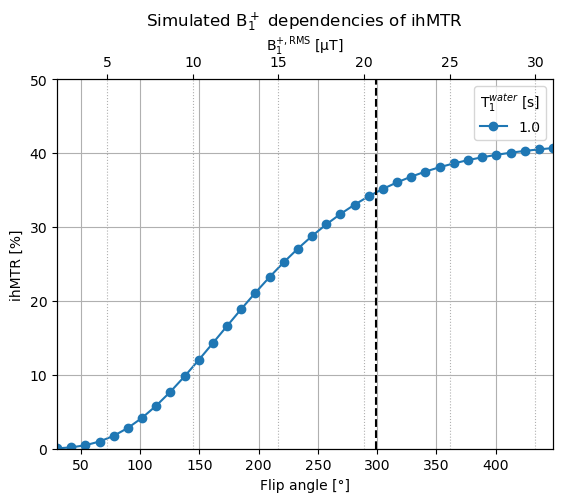

In [30]:
%load_ext autoreload
%autoreload 2

from brainhack.pulse import Tukey
from brainhack.sequence import Sequence, Modulation
from brainhack.system import System
from brainhack.simulator import Simulator
from brainhack.corrector import Corrector, Correctable

import matplotlib.pyplot as plt
import numpy as np

pulse = Tukey(
    duration = 1e-3,                    # in s
    shape = .3,
    flipAngle = 299,                    # in degree
    offset = 7000                       # in Hz
)

sequence = Sequence(
    modulation = Modulation.BP,
    pulse = pulse,
    N_pulsePerOffset = 1,
    N_pulse = 6,
    N_burst = 10,
    N_adc = 96,
    N_dummyADC = 0,
    dt_interPulse = 1.5e-3,             # in s
    TR_burst = 100e-3,                  # in s
    dt_lastBurst = 9e-3,                # in s
    es = 6e-3,                          # in s
    tr = 20,                            # in s
    readout_flipAngle = 6               # in degree
)

system = System(
    pulse = pulse,
    poolFree_M0 = 1,
    poolBound_M0 = 0.1,
    poolFree_T1 = 1,                    # in s
    poolBound_T1 = 1,                   # in s 
    poolBound_T1D = 0.01,               # in s
    poolFree_T2 = 0.1,                  # in s
    poolBound_T2 = 1e-5,                # in s
    poolFreeBound_exchangeRate = 20     # in s^-1
)

simulator = Simulator(
    system = system,
    sequence = sequence,
    output_vectorSlice = slice(1),
    export_readMatrix = False,
)

flipAngle_nominal = pulse.flipAngle
b1RMS_nominal = pulse.b1RMS * 1e6
B1rel_range = np.linspace(.1, 1.5, 36)
ihMTR_values = []

for B1rel in B1rel_range:
    pulse.flipAngle = flipAngle_nominal * B1rel
    out = simulator.SteadyState()
    ihMTR_temp = 2*(out['MTs'][0] - out['MTd_CM'][0]) / out['MT0'][0] * 100
    ihMTR_values.append(ihMTR_temp)

plt.plot(B1rel_range*flipAngle_nominal, ihMTR_values, marker='o', linestyle='-', label=f'{system.poolFree_T1}')
plt.vlines(flipAngle_nominal, 0, 50, 'k', 'dashed')
plt.legend(title=r'$\mathrm{T}_1^{water}$ [s]')
plt.xlabel('Flip angle [°]')
plt.xlim(min(B1rel_range * flipAngle_nominal), max(B1rel_range * flipAngle_nominal))
plt.ylim(0, 50)
plt.ylabel('ihMTR [%]')
plt.title(r'Simulated $\mathrm{B}_1^+$ dependencies of ihMTR')
plt.grid()

ax2 = plt.gca().twiny()
ax2.set_xlim(min(B1rel_range * b1RMS_nominal), max(B1rel_range * b1RMS_nominal))
ax2.set_xlabel(r'$\mathrm{B}_1^\mathrm{+,RMS}$ [µT]')
ax2.grid(linestyle='dotted')

plt.show()